**Import Libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.auto import trange
import os
import random


**Parameters for data preprocessing**

In [2]:
# Number of file to pick in both training and development set
# num_files_to_pick = 10000                                                             

### Filepaths LFCC ###
# Training
data_dir = 'D:\\Felipe\\Team Lab\\teamlab-phonetics\\feature_extraction\\mfcc_segment_outputs\\mfcc_training'

# Development/Validation
dev_data_dir = 'D:\\Felipe\\Team Lab\\teamlab-phonetics\\feature_extraction\\mfcc_segment_outputs\\mfcc_dev'


**Preprocessing of training data** 

In [3]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
features_list = []
labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(data_dir, file_name)
    feature, label = torch.load(file_path)
    features_list.append(feature)  # Append the tensors
    labels_list.append(label) # Append the labels

# Concatenate all the data into a single tensor
features = torch.stack(features_list)
print("Example of the features",features[1])
labels = torch.tensor(labels_list)
print("Example of the labels",labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

# Create a TensorDataset and DataLoader
dataset = TensorDataset(features, labels)
dataLoader = DataLoader(dataset, batch_size=64, shuffle=True)
print("The training dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[-8.9210e+02, -8.8179e+02, -8.6409e+02,  ..., -4.8430e+02,
         -4.3294e+02, -4.6942e+02],
        [ 1.8140e+01,  3.1632e+01,  4.5543e+01,  ..., -9.5127e+00,
          4.2357e+01,  7.8088e+01],
        [ 1.7448e+01,  2.8009e+01,  2.6739e+01,  ...,  6.2843e+01,
          4.1308e+01,  1.4769e+01],
        ...,
        [-2.1652e+00, -6.8170e+00, -7.0092e+00,  ..., -4.3740e+00,
         -2.7777e+00, -7.9133e+00],
        [-1.8964e+00, -6.0367e+00, -7.1292e+00,  ..., -4.0570e+00,
          2.9166e-01,  6.2781e-01],
        [-1.7427e+00, -5.3392e+00, -4.4981e+00,  ..., -5.9818e+00,
         -5.4255e+00, -8.2022e+00]])
Example of the features tensor([[-8.3976e+02, -8.2731e+02, -8.3390e+02,  ..., -6.8113e+02,
         -5.0474e+02, -4.7847e+02],
        [ 6.2343e+01,  6.9329e+01,  6.4993e+01,  ...,  1.1208e+02,
          1.2605e+02,  1.2671e+02],
        [ 1.7929e+01,  1.2520e+01,  1.2623e+01,  ..., -1.7738e+01,
         -2.9696e+01, -3.2636e+01],
        ...

**Dataset inspection**

In [4]:
# Inspect the range of labels in the dataset
#print("Minimum label value:", labels.min().item())
#print("Maximum label value:", labels.max().item())
#print("Unique label values:", torch.unique(labels))

# Inspect the first sample in the batch
print("First sample shape:", features[0].shape)
print("First sample values:\n", features[0])


# Inspect the concatenated tensor
#print("Data Tensor Shape:", data_tensor.shape)
#print("Data Tensor Data Type:", data_tensor.dtype)
#print("Sample Data Tensor Values:\n", data_tensor[:5])  # Print the first 5 rows

# Inspect features and labels
#print("Features Shape:", features.shape)
#print("Labels Shape:", labels.shape)
#print("Sample Features:\n", features[:5])  # Print the first 5 rows of features
print("Sample Labels:\n", labels[:100])  # Print the first 5 labels

First sample shape: torch.Size([40, 126])
First sample values:
 tensor([[-8.9210e+02, -8.8179e+02, -8.6409e+02,  ..., -4.8430e+02,
         -4.3294e+02, -4.6942e+02],
        [ 1.8140e+01,  3.1632e+01,  4.5543e+01,  ..., -9.5127e+00,
          4.2357e+01,  7.8088e+01],
        [ 1.7448e+01,  2.8009e+01,  2.6739e+01,  ...,  6.2843e+01,
          4.1308e+01,  1.4769e+01],
        ...,
        [-2.1652e+00, -6.8170e+00, -7.0092e+00,  ..., -4.3740e+00,
         -2.7777e+00, -7.9133e+00],
        [-1.8964e+00, -6.0367e+00, -7.1292e+00,  ..., -4.0570e+00,
          2.9166e-01,  6.2781e-01],
        [-1.7427e+00, -5.3392e+00, -4.4981e+00,  ..., -5.9818e+00,
         -5.4255e+00, -8.2022e+00]])
Sample Labels:
 tensor([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0

**Testing the Data Loader**

In [5]:
print(len(dataset[0][0]))
print(features.shape)

for batch in dataLoader:
    features, labels = batch
    print("Batch features shape:", features.shape)
    break

40
torch.Size([25380, 40, 126])
Batch features shape: torch.Size([64, 40, 126])


**Preprocessing and loading the Development/Validation Set**

In [6]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(dev_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(dev_data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
dev_features_list = []
dev_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(dev_data_dir, file_name)
    dev_feature, dev_label = torch.load(file_path)
    dev_features_list.append(dev_feature)  # Append the tensors
    dev_labels_list.append(dev_label) # Append the labels

# Concatenate all the data into a single tensor
dev_features = torch.stack(dev_features_list)
print("Example of the features",dev_features[1])
dev_labels = torch.tensor(dev_labels_list)
print("Example of the labels",dev_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", dev_features.shape)
print("Labels shape:", dev_labels.shape)

# Create a TensorDataset and DataLoader
dev_dataset = TensorDataset(dev_features, dev_labels)
dev_dataLoader = DataLoader(dev_dataset, batch_size=64, shuffle=False)
print("The development dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[-8.5672e+02, -7.1635e+02, -5.6287e+02,  ..., -3.8466e+02,
         -4.2659e+02, -4.9261e+02],
        [ 5.9765e+01,  1.0991e+02,  1.3010e+02,  ...,  9.3315e+01,
          1.2963e+02,  1.0779e+02],
        [ 3.9769e+01,  1.9662e+01, -3.4860e+01,  ..., -4.5258e+01,
         -7.7143e+01, -4.0632e+01],
        ...,
        [ 3.9317e-01, -7.6469e+00,  9.6451e-02,  ...,  1.4098e+01,
          1.8001e+01,  6.5074e+00],
        [-1.9767e+00, -4.2551e+00, -2.3172e+00,  ...,  7.8047e+00,
          2.6131e+01,  2.4507e+01],
        [-3.9627e+00, -8.2655e-01, -5.9821e+00,  ...,  4.5397e+00,
          1.2519e+01,  1.7426e+01]])
Example of the features tensor([[-8.6674e+02, -8.6741e+02, -8.7958e+02,  ..., -4.9077e+02,
         -4.7417e+02, -4.8447e+02],
        [ 4.8346e+01,  4.9906e+01,  3.4838e+01,  ..., -7.7853e+01,
         -3.5630e+01,  3.9631e+00],
        [ 3.4704e+01,  4.0697e+01,  3.1309e+01,  ...,  5.2765e+01,
          7.0477e+01,  6.2291e+01],
        ...

**Testing the Processed Dataloaders and Label Distribution**

In [7]:
print("Training features shape",features.shape,"[1] batch size | [2] Coefficients | [3] Timeframes")
print("Training labels shape",labels.shape)
print("Development features shape:", dev_features.shape,"[1] batch size | [2] Coefficients | [3] Timeframes")
print("Development labels shape:", dev_labels.shape)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training features shape torch.Size([64, 40, 126]) [1] batch size | [2] Coefficients | [3] Timeframes
Training labels shape torch.Size([64])
Development features shape: torch.Size([24844, 40, 126]) [1] batch size | [2] Coefficients | [3] Timeframes
Development labels shape: torch.Size([24844])
Training label distribution: tensor([54, 10])
Validation label distribution: tensor([22296,  2548])


**Hyperparemeters**

In [35]:
hidden_dim = 128  # Number of neurons in the hidden layer
dropout_prob = 0.5  # Dropout probability

**Neural Network Model**

In [36]:
class SpoofDetectionModel(nn.Module):
    def __init__(self, hidden_dim, dropout_prob):
        super(SpoofDetectionModel, self).__init__()
        
        # 1D Convolutional layers
        self.conv1 = nn.Conv1d(in_channels=40, out_channels=32, kernel_size=3, stride=1, padding=1) # in channels = LFCC coefficients
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout_prob)
        
        # Fully connected layers
        self.fc1 = None  # Placeholder, will be initialized dynamically
        self.fc3 = nn.Linear(hidden_dim, 1)  # Single output neuron for binary classification
        
        # Initialize weights
        self.init_weights()
        
    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                torch.nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)
        
    def forward(self, x):
        # Input x is already (batch_size, num_channels, sequence_length) for MFCC: [batch, 40, 126]
        
        # Convolutional layers
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout(x)  # Apply dropout after convolutional layers
        
        # Flatten the output for the fully connected layer
        x = x.view(x.size(0), -1)
        
        # Dynamically initialize fc1 if not already done
        if self.fc1 is None:
            self.fc1 = nn.Linear(x.size(1), hidden_dim).to(x.device)
        
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)  # Apply dropout after the first fully connected layer
        x = self.fc3(x)  # Output layer: Sigmoid for binary classification / previous line (before BCEwithLogits): x = torch.sigmoid(self.fc3(x))
        
        return x

**Initializing the model**

In [37]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SpoofDetectionModel(hidden_dim, dropout_prob).to(device)

**Calculate the weights proportion for weighted loss**

In [38]:
'''Formula: weight_for_class_i = total_samples / (num_samples_in_class_i * num_classes)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training label distribution: tensor([26,  6])
Validation label distribution: tensor([8949, 1051])
'''

# Proportion of samples of the development set
counts = torch.bincount(dev_labels) # tensor with [SPOOF, BONAFIDE]
proportions = counts / len(dev_labels) * 100
prop_spoof = float(proportions[0])
prop_bonafide = float(proportions[1])
print("Proportion of the Development Set:\n",f"Spoof: {prop_spoof:.2f}% | Bonafide: {prop_bonafide:.2f}%")


weight_for_class_0 = (len(dev_labels) / (torch.bincount(dev_labels)[0] * 2))
print("Weight of class 0 (spoof):",weight_for_class_0)

weight_for_class_1 = (len(dev_labels) / (torch.bincount(dev_labels)[1] * 2))
print("Weight of class 1 (bonafide):",weight_for_class_1)

weighted_loss_pos = torch.tensor(weight_for_class_1)
print("Weight tensor to be passed to the Loss Function",weighted_loss_pos)

Proportion of the Development Set:
 Spoof: 89.74% | Bonafide: 10.26%
Weight of class 0 (spoof): tensor(0.5571)
Weight of class 1 (bonafide): tensor(4.8752)
Weight tensor to be passed to the Loss Function tensor(4.8752)


C:\Users\fnobrega\AppData\Local\Temp\ipykernel_12428\4247703482.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weighted_loss_pos = torch.tensor(weight_for_class_1)


**Loss function and Optimizer**

In [39]:
criterion = nn.BCEWithLogitsLoss(pos_weight=weighted_loss_pos)  # Binary cross-entropy loss
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)  # Learning rate + weight decay

**Metric Initialization / Learning Scheduler / Early stopping**

In [41]:
import matplotlib.pyplot as plt

# Initialize lists to store metrics
losses_train = [] # Stores the average training loss for each epoch.
losses_val = [] # Stores the average validation loss for each epoch.
accuracies_train = [] # Stores the training accuracy for each epoch.
accuracies_val = [] # Stores the validation accuracy for each epoch.
eers_val = []

### Learning rate scheduler to reduce the learning rate during training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Initialize variables for early stopping
best_eer = float('inf')  # Track the best validation loss
patience = 5  # Number of epochs to wait for improvement
counter = 0   # Counter for early stopping



**Training Loop**

In [42]:
import numpy as np
from sklearn.metrics import roc_curve, f1_score
from scipy.special import expit  # sigmoid function
# Training loop
num_epochs = 100

def calculate_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer * 100, thresholds[eer_idx]

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    epoch_loss_train = 0.0
    correct_train = 0
    total_train = 0

    # Training phase
    for batch_idx, (features, labels) in enumerate(dataLoader):
        features, labels = features.to(device), labels.to(device) #for LFCC -> old code, possibly for wav2vec: features, labels = features.unsqueeze(1).to(device), labels.to(device)
        
        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, labels.float().unsqueeze(1))  # Reshape labels to [batch_size, 1]

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training loss and accuracy
        epoch_loss_train += loss.item()
        predicted = (outputs > 0).float()
        total_train += labels.size(0)
        correct_train += (predicted.squeeze() == labels).sum().item()

    # Compute average training loss and accuracy for the epoch
    avg_loss_train = epoch_loss_train / len(dataLoader)
    accuracy_train = 100 * correct_train / total_train
    losses_train.append(avg_loss_train)
    accuracies_train.append(accuracy_train)

    # -------- VALIDATION PHASE + EER --------
    model.eval()
    epoch_loss_val = 0.0
    correct_val = 0
    total_val = 0
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dev_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1)) # Reshape labels to [batch_size, 1]

            # Accumulate validation loss and accuracy
            epoch_loss_val += loss.item()
            predicted = (outputs > 0).float()
            correct_val += (predicted.squeeze() == labels).sum().item()
            total_val += labels.size(0)

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy())

    # Compute average validation loss and accuracy for the epoch
    avg_loss_val = epoch_loss_val / len(dev_dataLoader)
    accuracy_val = 100 * correct_val / total_val
    losses_val.append(avg_loss_val)
    accuracies_val.append(accuracy_val)

    # --- Calculate EER on validation set ---
    eer_val, threshold_val = calculate_eer(np.array(all_labels), np.array(all_scores))
    eers_val.append(eer_val)

    # Print metrics
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_loss_train:.4f}, Acc: {accuracy_train:.2f}% | "
          f"Val Loss: {avg_loss_val:.4f}, Acc: {accuracy_val:.2f}% | "
          f"Val EER: {eer_val:.2f}% | "
          f"Val Threshold: {threshold_val:.2f}%")

    # Learning rate scheduling
    scheduler.step(avg_loss_val)

    # --- Early Stopping Based on Validation EER ---
    if eer_val < best_eer:
        best_eer = eer_val
        best_threshold = threshold_val  # Save the threshold for best EER
        torch.save(model.state_dict(), 'saved_models/mfcc_v5_best_model.pth')
    # Save the threshold to a file
        with open('saved_models/mfcc_v5_best_threshold.txt', 'w') as f:
            f.write(f"Best EER during Validation: {float(best_eer)}\n")
            f.write(f"Best Threshold during Validation: {float(best_threshold)}\n")
        counter = 0
    else:
        counter += 1
        print(f"EER not improved. Patience counter: {counter}/{patience}")
        if counter >= patience and epoch >= 10:
            print("Early stopping triggered (EER did not improve).")
            break

Epoch [1/100] | Train Loss: 30.2898, Acc: 60.81% | Val Loss: 2.3475, Acc: 82.45% | Val EER: 30.07% | Val Threshold: -5.16%
Epoch [2/100] | Train Loss: 9.9313, Acc: 64.93% | Val Loss: 1.1258, Acc: 85.73% | Val EER: 23.63% | Val Threshold: -2.74%
Epoch [3/100] | Train Loss: 3.1347, Acc: 69.91% | Val Loss: 0.7415, Acc: 84.43% | Val EER: 24.92% | Val Threshold: -1.19%
EER not improved. Patience counter: 1/5
Epoch [4/100] | Train Loss: 1.4715, Acc: 68.85% | Val Loss: 0.7173, Acc: 81.39% | Val EER: 27.75% | Val Threshold: -0.43%
EER not improved. Patience counter: 2/5
Epoch [5/100] | Train Loss: 0.9745, Acc: 71.02% | Val Loss: 0.6935, Acc: 83.64% | Val EER: 24.43% | Val Threshold: -0.31%
EER not improved. Patience counter: 3/5
Epoch [6/100] | Train Loss: 0.8673, Acc: 73.36% | Val Loss: 0.6904, Acc: 86.87% | Val EER: 21.78% | Val Threshold: -0.30%
Epoch [7/100] | Train Loss: 0.7982, Acc: 75.78% | Val Loss: 0.6621, Acc: 86.48% | Val EER: 19.16% | Val Threshold: -0.21%
Epoch [8/100] | Train Los

In [56]:
print(threshold_val)

-2.0188966


**Plotting the results**

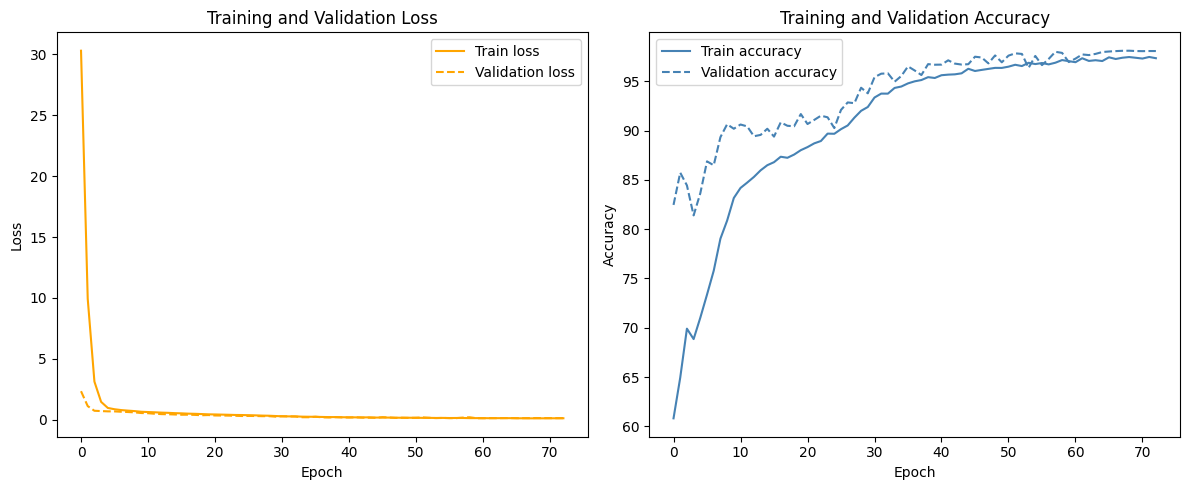

In [43]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(losses_train, color="orange", linestyle="-", label="Train loss")
plt.plot(losses_val, color="orange", linestyle="--", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(accuracies_train, color="steelblue", linestyle="-", label="Train accuracy")
plt.plot(accuracies_val, color="steelblue", linestyle="--", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Saving the model** (Actually don't do it, use the version saved in early stopping)

In [ ]:
# Save weights only
#torch.save(model.state_dict(), 'lfcc_with_delta_v3_updated_model_deepfake_audio_detection_model.pth')

# Save the full model (architecture + weights)
#torch.save(model, 'lfcc_with_delta_v2_updated_model_deepfake_audio_detection_model_full.pt')

**Prepare Evaluation Dataset**

In [24]:
# Evaluation
eval_data_dir = 'D:\\Felipe\\Team Lab\\teamlab-phonetics\\feature_extraction\\mfcc_segment_outputs\\mfcc_eval_set'

# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(eval_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(eval_data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
eval_features_list = []
eval_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(eval_data_dir, file_name)
    eval_feature, eval_label = torch.load(file_path)
    eval_features_list.append(eval_feature)  # Append the tensors
    eval_labels_list.append(eval_label) # Append the labels

# Concatenate all the data into a single tensor
eval_features = torch.stack(eval_features_list)
print("Example of the features",eval_features[1])
eval_labels = torch.tensor(eval_labels_list)
print("Example of the labels",eval_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", eval_features.shape)
print("Labels shape:", eval_labels.shape)

# Create a TensorDataset and DataLoader
eval_dataset = TensorDataset(eval_features, eval_labels)
eval_dataLoader = DataLoader(eval_dataset, batch_size=32, shuffle=False)
print("The evaluation dataset has been successfully loaded into DataLoader.")


Example of the .pt file tensor([[-4.6451e+02, -2.5786e+02, -1.3042e+02,  ..., -9.4785e+01,
         -1.0378e+02, -1.0388e+02],
        [ 1.2610e+02,  1.7758e+02,  1.7961e+02,  ...,  1.7845e+02,
          1.6337e+02,  1.5409e+02],
        [ 5.0402e+01,  4.3320e+00, -4.3096e+01,  ..., -8.4626e+01,
         -7.0924e+01, -6.0761e+01],
        ...,
        [-8.1875e+00, -4.6580e+00, -5.9014e+00,  ..., -1.2979e+01,
         -5.1512e+00, -6.8142e+00],
        [-4.6463e+00, -7.8961e+00, -1.4879e+01,  ..., -1.4200e+01,
         -6.2371e+00, -5.1082e+00],
        [-2.6891e+00, -6.8606e+00, -3.5361e+00,  ..., -1.0373e+01,
         -3.6374e+00, -1.1208e-01]])
Example of the features tensor([[-533.8523, -547.8169, -418.2567,  ..., -551.3339, -552.1827,
         -548.4077],
        [  32.8076,   38.7698,  108.6318,  ...,   35.9218,   35.4762,
           40.3420],
        [  16.7653,   31.2666,   17.0167,  ...,   31.4240,   32.7342,
           36.4258],
        ...,
        [  -3.1965,   -4.7255,   -


Evaluation Set:
Loss: 2.5124 | Accuracy: 90.23%
EER: 16.81% | Logit Threshold: -8.4729 | Prob Threshold: 0.0002
F1 Score: 0.5055
Precision: 0.3630
Recall: 0.8320
Predictions: [1]: 16855 | [0]: 54382


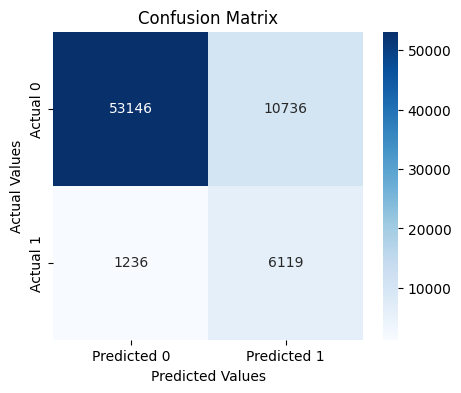

In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

def evaluate_on_eval_set(model, eval_dataLoader):
    model.eval()
    all_scores = []
    all_labels = []
    total = 0
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for features, labels in eval_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1))

            total_loss += loss.item()
            predicted = (outputs > 0).float()
            correct += (predicted.squeeze() == labels).sum().item()
            total += labels.size(0)

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy())

    # Convert to NumPy arrays
    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)
    
    # Metrics
    avg_loss = total_loss / len(eval_dataLoader)
    accuracy = 100 * correct / total
    eer, threshold = calculate_eer(all_labels, all_scores)
    prob_threshold = expit(threshold)
    preds = (all_scores >= threshold).astype(int)
    
    # Calculate precision and recall
    precision = precision_score(all_labels, preds)
    recall = recall_score(all_labels, preds)
    f1 = f1_score(all_labels, preds)

    # Print results with precision and recall
    print(f"\nEvaluation Set:")
    print(f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
    print(f"EER: {eer:.2f}% | Logit Threshold: {threshold:.4f} | Prob Threshold: {prob_threshold:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Predictions: [1]: {np.count_nonzero(preds == 1)} | [0]: {np.count_nonzero(preds == 0)}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted Values')
    plt.ylabel('Actual Values')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_on_eval_set(model, eval_dataLoader)